In [40]:
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
%matplotlib inline
from collections import Counter

In [41]:
data = pd.read_csv('./improved_disease_dataset.csv')

In [42]:
data.head()

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes,disease
0,1,0,1,0,1,0,0,1,1,0,Paralysis (brain hemorrhage)
1,0,0,1,0,0,0,1,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,0,1,1,0,0,Paralysis (brain hemorrhage)
3,0,0,1,1,1,0,1,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,0,0,0,1,1,Paralysis (brain hemorrhage)


In [43]:
data.isna().sum()

fever          0
headache       0
nausea         0
vomiting       0
fatigue        0
joint_pain     0
skin_rash      0
cough          0
weight_loss    0
yellow_eyes    0
disease        0
dtype: int64

In [44]:
encoder = LabelEncoder()
data['disease'] = encoder.fit_transform(data['disease'])

In [45]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

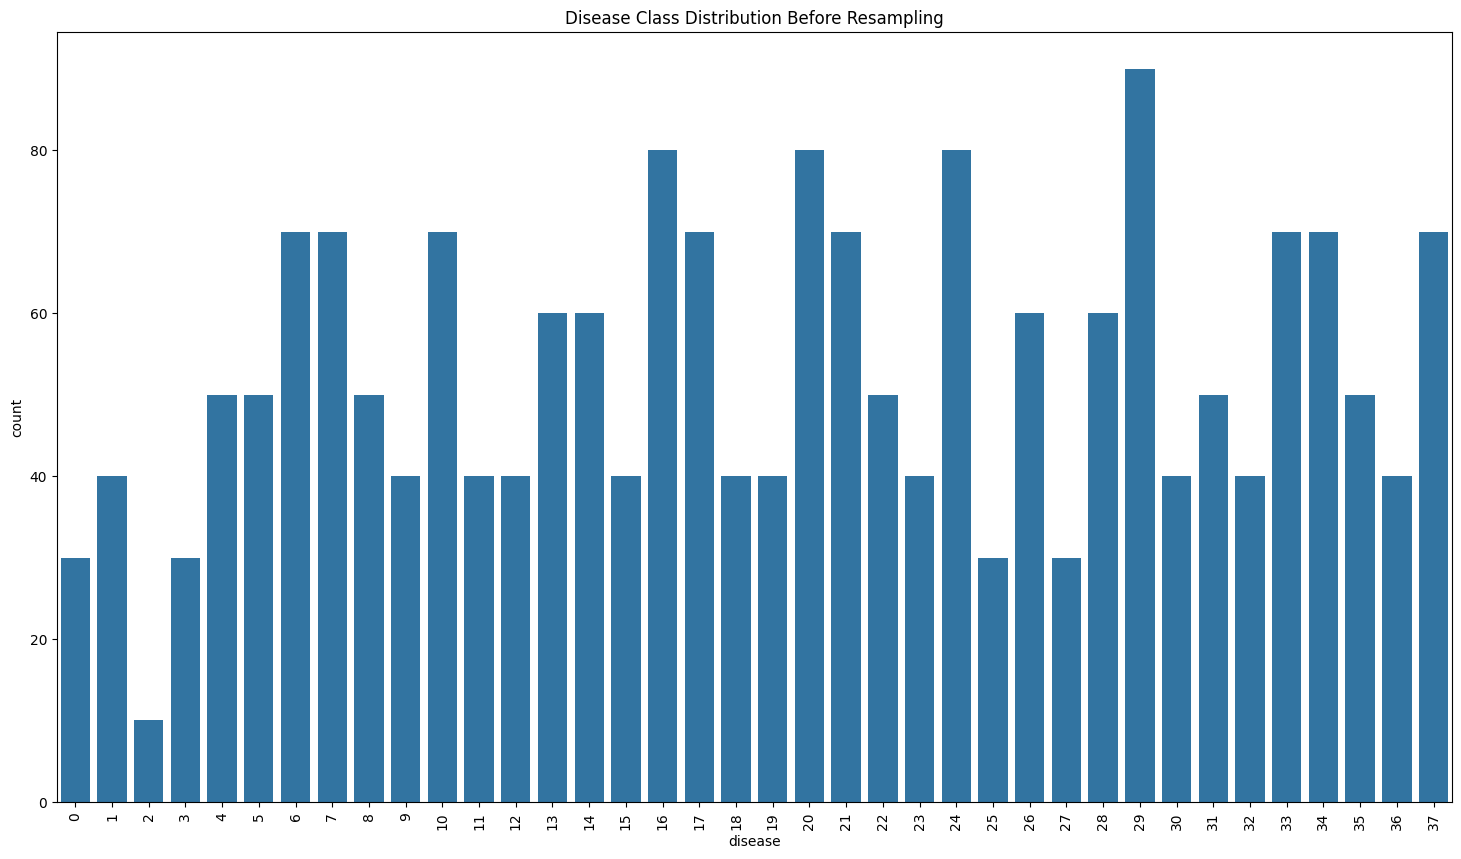

In [46]:
plt.figure(figsize=(18,10))
sns.countplot(x=y)
plt.title('Disease Class Distribution Before Resampling')
plt.xticks(rotation=90)
plt.show()

In [47]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [48]:
if 'gender' in X_resampled.columns:
    le = LabelEncoder()
    X_resampled['gender'] = le.fit_transform(X_resampled['gender'])

X_resampled = X_resampled.fillna(0)

if len(y_resampled.shape) > 1:
    y_resampled = y_resampled.values.ravel()

X_resampled

,fever,headache,nausea,vomiting,fatigue,joint_pain,skin_rash,cough,weight_loss,yellow_eyes
0,1,0,1,0,1,0,0,1,1,0
1,0,0,1,0,0,0,1,1,0,0
2,0,0,1,0,1,0,1,1,0,0
3,0,0,1,1,1,0,1,1,1,1
4,1,0,1,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...
3415,0,0,1,1,0,0,0,0,0,1
3416,0,0,0,1,0,1,0,0,0,1
3417,0,0,0,1,0,1,0,0,0,1
3418,0,0,0,0,0,1,1,0,0,0


In [49]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC()
}

In [50]:
cv_scoring = 'accuracy' # U can use 'f1_weighted' or 'roc_auc_ovr' for multi-class
Stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    try:
        scores = cross_val_score(
            model, X_resampled, y_resampled, cv=Stratified_kfold, 
            scoring=cv_scoring, n_jobs=-1, error_score='raise'
        )
        print('=' * 50)
        print(f'Model: {model_name}')
        print(f'Scores:  {scores}')
        print(f'Mean Accuracy: {scores.mean():.4f}')
    except Exception as e:
        print('=' * 50)
        print(f'Model: {model_name} failed with error: {e}')


Model: Decision Tree
Scores:  [0.5497076  0.54532164 0.5380117  0.53654971 0.52777778]
Mean Accuracy: 0.5395
Model: Random Forest
Scores:  [0.5497076  0.53070175 0.53947368 0.53508772 0.52192982]
Mean Accuracy: 0.5354
Model: SVM
Scores:  [0.51315789 0.51169591 0.49707602 0.48245614 0.49561404]
Mean Accuracy: 0.5000


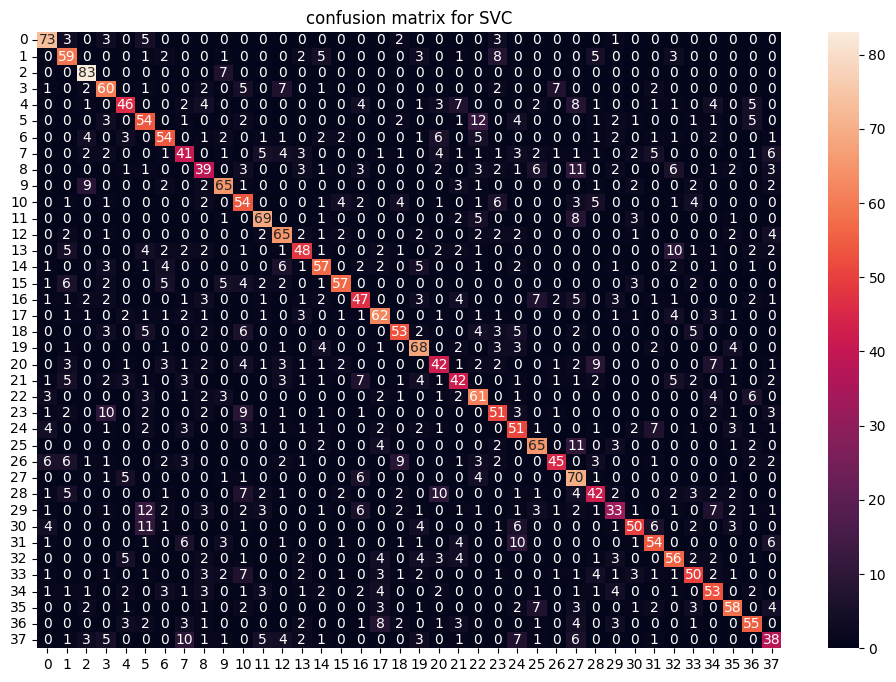

SVC accuracy: 60.526%


In [51]:
svm_model = SVC()
svm_model.fit(X_resampled, y_resampled)
svm_preds = svm_model.predict(X_resampled)

cf_mat_svm = confusion_matrix(y_resampled, svm_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_mat_svm, annot=True, fmt='d')
plt.title('confusion matrix for SVC')
plt.show()

print(f'SVC accuracy: {accuracy_score(y_resampled, svm_preds)*100:.3f}%')

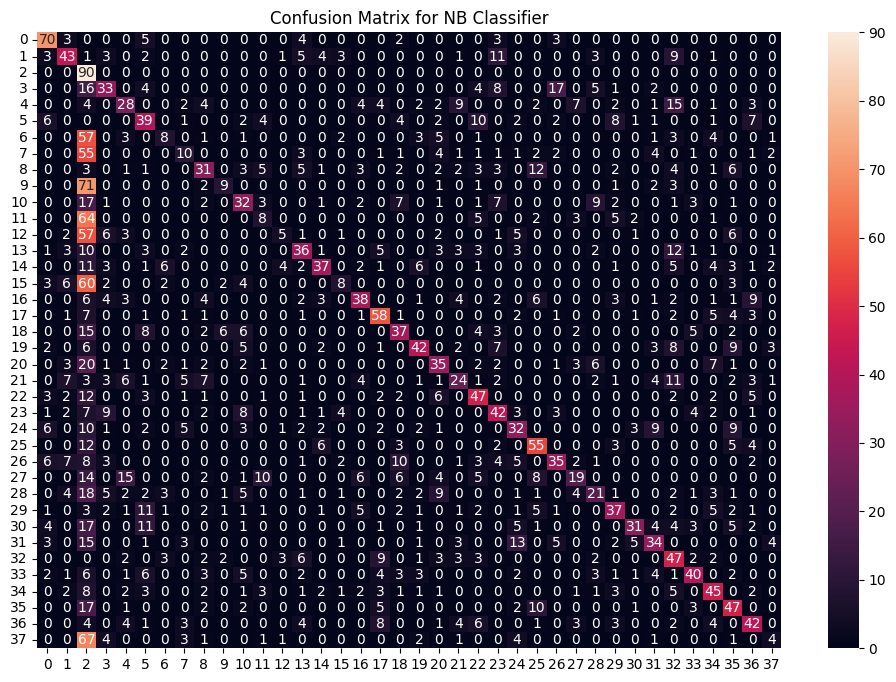

NB Accuracy: 37.98%


In [52]:
nb_model = GaussianNB()
nb_model.fit(X_resampled, y_resampled)
nb_preds = nb_model.predict(X_resampled)

cf_matrix_nb = confusion_matrix(y_resampled, nb_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_nb, annot=True, fmt="d")
plt.title("Confusion Matrix for NB Classifier")
plt.show()

print(f"NB Accuracy: {accuracy_score(y_resampled, nb_preds) * 100:.2f}%")

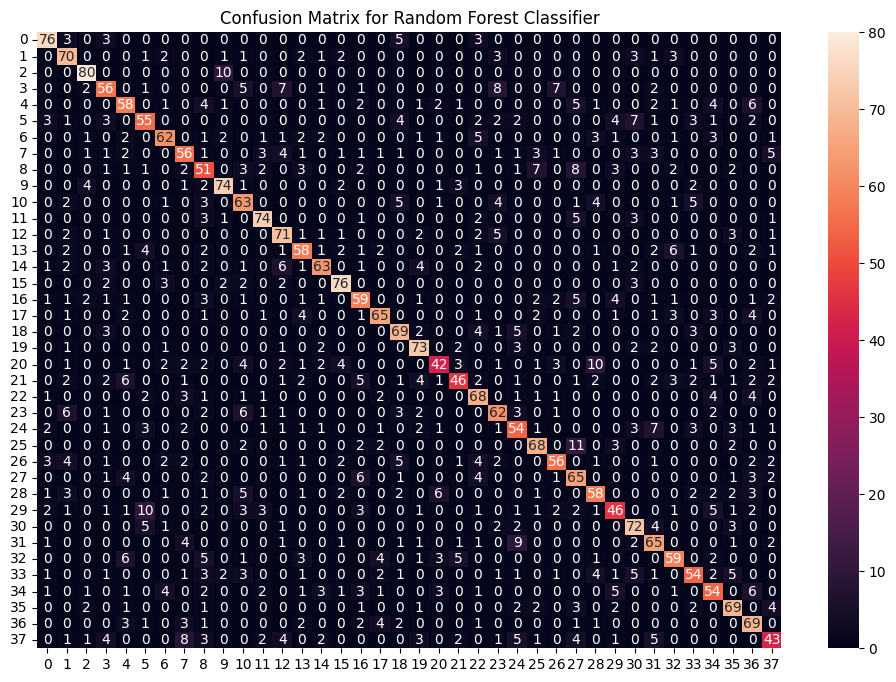

Random Forest Accuracy: 68.98%


In [53]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)
rf_preds = rf_model.predict(X_resampled)

cf_matrix_rf = confusion_matrix(y_resampled, rf_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cf_matrix_rf, annot=True, fmt="d")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

print(f"Random Forest Accuracy: {accuracy_score(y_resampled, rf_preds) * 100:.2f}%")

In [54]:
symptoms = X.columns.values
symptom_index = {symptom: idx for idx, symptom in enumerate(symptoms)}

def predict_disease(input_symptoms):
    # .strip() handles "symptom1, symptom2" (with spaces)
    input_symptoms = [s.strip() for s in input_symptoms.split(",")]
    input_data = [0] * len(symptom_index)
    
    for symptom in input_symptoms:
        if symptom in symptom_index:
            input_data[symptom_index[symptom]] = 1
        else:
            print(f"Warning: Symptom '{symptom}' not recognized.")

    input_df = pd.DataFrame([input_data], columns=symptoms)

    # Predictions
    rf_pred = encoder.classes_[rf_model.predict(input_df)[0]]
    nb_pred = encoder.classes_[nb_model.predict(input_df)[0]]
    svm_pred = encoder.classes_[svm_model.predict(input_df)[0]]

    # Robust Majority Voting
    preds = [rf_pred, nb_pred, svm_pred]
    final_pred = Counter(preds).most_common(1)[0][0]
    
    return {
        "RF": rf_pred,
        "NB": nb_pred,
        "SVM": svm_pred,
        "Final": final_pred
    }

print(predict_disease("skin_rash,fever,headache"))

{'RF': 'Peptic ulcer disease', 'NB': 'Impetigo', 'SVM': 'Peptic ulcer disease', 'Final': 'Peptic ulcer disease'}
